# Lab 5: MNIST CNN Classifier

**COMP 395 — Deep Learning**
**Due: March 20, 2026**
**Individual assignment**

---

## Overview

In this lab you will train convolutional neural networks to classify handwritten digits from the MNIST dataset. You will start by training an MLP baseline, then build and train the `SimpleCNN` from our in-class lab, and finally experiment with architectural modifications — all tracked with MLflow.

This lab is intentionally less scaffolded than previous labs. You have done every individual piece before (data loading, training loops, evaluation, MLflow logging). The challenge here is putting them together independently in a new context.

## Setup

You will need the following libraries. Refer to your earlier labs if you don't remember how any of these work.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Part 1: Data Loading and Preprocessing

We load the MNIST dataset using `torchvision`. The key steps:

- `transforms.ToTensor()` converts PIL images to PyTorch tensors and scales pixel values from [0, 255] to [0, 1]. It also rearranges the shape to `(C, H, W)` — the format `nn.Conv2d` expects.
- `transforms.Normalize((0.1307,), (0.3081,))` standardizes using the MNIST dataset's global mean and standard deviation. This centers the data around zero, which helps training converge faster.
- We create separate `DataLoader`s for training and testing. The training loader shuffles; the test loader does not (shuffling the test set would change nothing about evaluation, but ordered data is easier to inspect).

In [2]:
# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL -> tensor, scales to [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),   # standardize with MNIST mean/std
])

# Download and load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Batch size:       {batch_size}")

100.0%
100.0%
100.0%
100.0%


Training samples: 60000
Test samples:     10000
Batch size:       64


### 1.1 Understanding the DataLoader

Before you start training, take a moment to understand what the `DataLoader` is actually giving you. A `DataLoader` wraps a dataset and provides:

- **Batching:** instead of feeding one image at a time, it groups images into batches (e.g., 64 at once). This is more efficient for the GPU and provides a more stable gradient estimate.
- **Shuffling:** randomizes the order each epoch so the model doesn't memorize the sequence.
- **An iterator:** you loop over it with `for images, labels in dataloader:` and it yields one batch at a time.

Run the cell below to inspect what comes out of the DataLoader.

In [3]:
# Grab one batch from the training DataLoader
images, labels = next(iter(train_loader))

print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")
print(f"Label dtype: {labels.dtype}")
print()

# Unpack the shape
N, C, H, W = images.shape
print(f"  N = {N}  (batch size — number of images in this batch)")
print(f"  C = {C}  (channels — 1 for grayscale, 3 for RGB)")
print(f"  H = {H}  (height in pixels)")
print(f"  W = {W}  (width in pixels)")
print()

# Pixel value range after your transforms
print(f"Pixel value range: [{images.min():.4f}, {images.max():.4f}]")
print(f"  (If you normalized with mean=0.1307, std=0.3081,")
print(f"   these won't be [0,1] anymore — that's expected.)")
print()

# What does one label look like?
print(f"First 10 labels in this batch: {labels[:10].tolist()}")
print(f"  (These are integers 0-9, one per image.)")

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])
Label dtype: torch.int64

  N = 64  (batch size — number of images in this batch)
  C = 1  (channels — 1 for grayscale, 3 for RGB)
  H = 28  (height in pixels)
  W = 28  (width in pixels)

Pixel value range: [-0.4242, 2.8215]
  (If you normalized with mean=0.1307, std=0.3081,
   these won't be [0,1] anymore — that's expected.)

First 10 labels in this batch: [0, 0, 9, 1, 8, 1, 0, 6, 0, 6]
  (These are integers 0-9, one per image.)


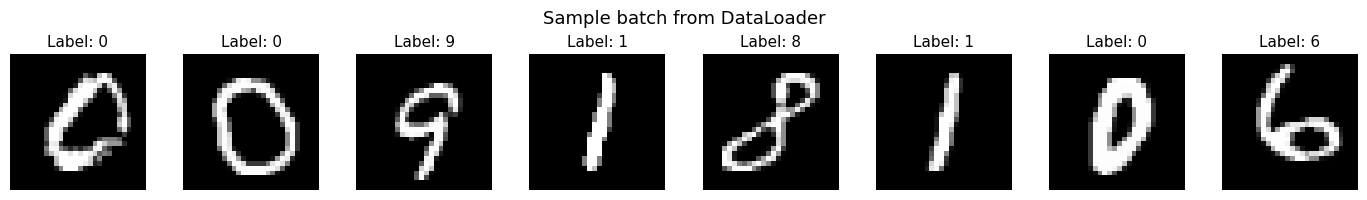

In [4]:
# Visualize a few images from the batch to confirm everything looks right
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    # images[i] has shape (C, H, W) — squeeze out the channel dim for grayscale
    img = images[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}", fontsize=11)
    axes[i].axis('off')
plt.suptitle("Sample batch from DataLoader", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 How the DataLoader fits into training

When you write a training loop, the DataLoader is what you iterate over:

```python
for epoch in range(num_epochs):
    for images, labels in train_loader:   # <-- one batch at a time
        outputs = model(images)            # forward pass on the batch
        loss = criterion(outputs, labels)  # compute loss for the batch
        ...
```

Each call to the loop yields a fresh batch. After you've gone through every batch once, that's one **epoch**. The DataLoader handles all the bookkeeping of which samples have been used, reshuffling, etc.

**Checkpoint:** Before moving on, make sure you can answer:

1. What is the shape of a single batch of images from your DataLoader?
2. What do the labels look like — are they integers or one-hot vectors?
3. How many batches are in one epoch? (Hint: `len(train_loader)`)

---

In [5]:
# How many batches per epoch?
print(f"Training batches per epoch: {len(train_loader)}")
print(f"  = {len(train_loader.dataset)} images / {train_loader.batch_size} per batch")

Training batches per epoch: 938
  = 60000 images / 64 per batch


## Part 2: MLP Baseline

Before building a CNN, we train a simple MLP on MNIST as a baseline. This gives you a point of comparison and — just as importantly — establishes the training loop and evaluation code that you'll reuse for every experiment that follows.

Study this section carefully. For Parts 3–5, you'll swap in a different model but keep everything else.

### 2.1 Model Definition

The MLP flattens each 28×28 image into a 784-dimensional vector and passes it through fully connected layers. This throws away all spatial structure — the model has no idea that pixel (0,0) is next to pixel (0,1). That's exactly the limitation CNNs will fix.

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()              # (N, 1, 28, 28) -> (N, 784)
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                         # raw logits — no softmax here
        return x

mlp_model = MLP()

# Count parameters
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP parameters: {total_params:,}")
print(f"  fc1: 784 × 256 + 256 = {784*256 + 256:,}")
print(f"  fc2: 256 × 128 + 128 = {256*128 + 128:,}")
print(f"  fc3: 128 × 10  + 10  = {128*10 + 10:,}")

MLP parameters: 235,146
  fc1: 784 × 256 + 256 = 200,960
  fc2: 256 × 128 + 128 = 32,896
  fc3: 128 × 10  + 10  = 1,290


### 2.2 Training Loop

This is the same train loop pattern from Lab 4. We use cross-entropy loss (which expects raw logits, not softmax outputs) and Adam optimizer.

We also define an `evaluate` function that we'll reuse for every experiment.

In [7]:
def evaluate(model, data_loader):
    """Compute accuracy and collect all predictions for a model on a DataLoader."""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)

In [8]:
# Training setup
num_epochs = 10
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

# Training loop
mlp_loss_history = []

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # Forward pass
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        # Backward pass and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    mlp_loss_history.append(avg_loss)

    # Check accuracy every few epochs
    if (epoch + 1) % 2 == 0 or epoch == 0:
        acc, _, _ = evaluate(mlp_model, test_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Test Acc: {acc:.4f}")

Epoch [1/10]  Loss: 0.2296  Test Acc: 0.9671
Epoch [2/10]  Loss: 0.0921  Test Acc: 0.9713
Epoch [4/10]  Loss: 0.0519  Test Acc: 0.9735
Epoch [6/10]  Loss: 0.0353  Test Acc: 0.9811
Epoch [8/10]  Loss: 0.0261  Test Acc: 0.9800
Epoch [10/10]  Loss: 0.0204  Test Acc: 0.9766


### 2.3 Evaluation

MLP final test accuracy: 0.9766


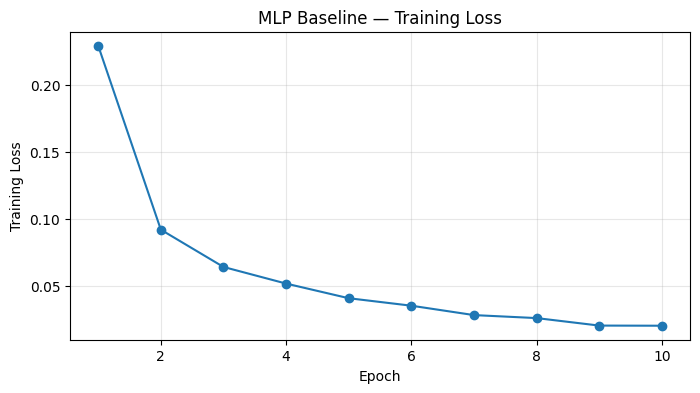

In [9]:
# Final evaluation
mlp_accuracy, mlp_preds, mlp_labels = evaluate(mlp_model, test_loader)
print(f"MLP final test accuracy: {mlp_accuracy:.4f}")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), mlp_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Baseline — Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

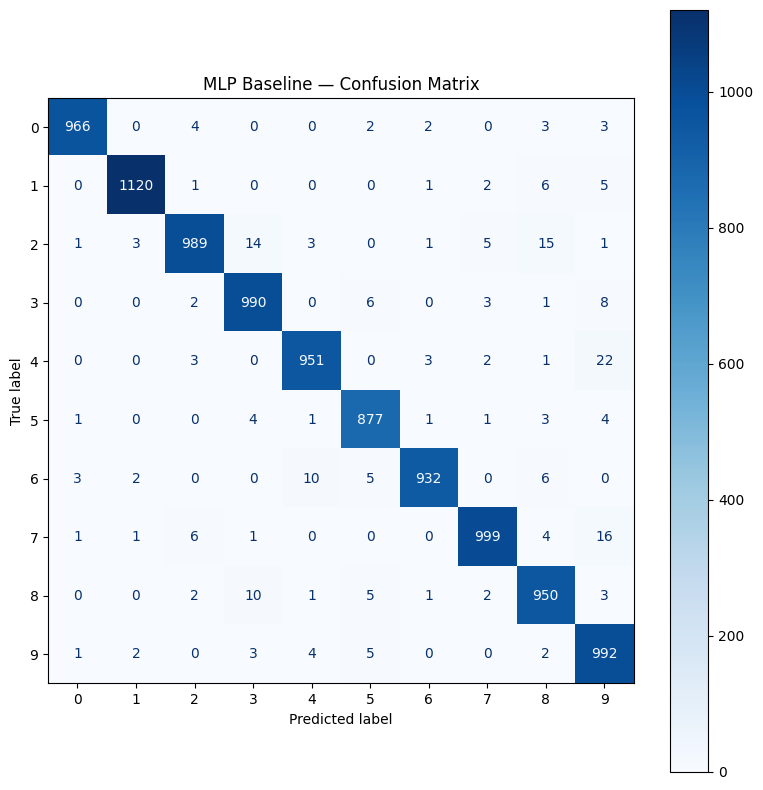

Saved mlp_confusion_matrix.png


In [10]:
# Confusion matrix
cm = confusion_matrix(mlp_labels, mlp_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("MLP Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("mlp_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved mlp_confusion_matrix.png")

### 2.4 MLflow Logging (Optional — Do This Now or in Part 6)

The cell below logs everything for this run. You can run it now or come back during Part 6. Either way, you'll need to do this for every experiment, so it's worth getting it working here first.

In [11]:
# Uncomment and run when you're ready to log to MLflow
# (Make sure your MLflow tracking server/URI is configured from earlier labs)

# mlflow.set_experiment("Lab5-MNIST")
#
# with mlflow.start_run(run_name="MLP-baseline"):
#     # Parameters
#     mlflow.log_param("model_type", "MLP")
#     mlflow.log_param("learning_rate", learning_rate)
#     mlflow.log_param("batch_size", batch_size)
#     mlflow.log_param("num_epochs", num_epochs)
#     mlflow.log_param("optimizer", "Adam")
#
#     # Tag
#     mlflow.set_tag("architecture", "MLP-784-256-128-10")
#
#     # Metrics — log loss for each epoch
#     for epoch, loss_val in enumerate(mlp_loss_history):
#         mlflow.log_metric("train_loss", loss_val, step=epoch + 1)
#     mlflow.log_metric("test_accuracy", mlp_accuracy)
#
#     # Artifact — confusion matrix
#     mlflow.log_artifact("mlp_confusion_matrix.png")
#
#     print(f"Logged MLP baseline: accuracy={mlp_accuracy:.4f}")

---

### What to reuse for Parts 3–5

When you build your CNN and run experiments, you should reuse:

- **`evaluate()`** — works with any model, no changes needed.
- **The training loop** — the only thing that changes is which model and optimizer you pass in. Consider wrapping it in a function:

```python
def train_model(model, train_loader, num_epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        loss_history.append(running_loss / len(train_loader))
    return loss_history
```

- **The confusion matrix code** — just change the filename and title.
- **The MLflow logging pattern** — change the run name, tag, and parameters.

---

## Part 3: CNN Classifier

Now build and train a CNN on the same data. You can use the `SimpleCNN` from the Day 2 in-class lab, or write your own architecture.

**Requirements:**

- At least two convolutional layers with ReLU and max pooling.
- A fully connected classification head that outputs 10 classes.
- Train using cross-entropy loss and an appropriate optimizer.
- Log the run to MLflow.
- Record the final test accuracy and compare to your MLP baseline.

The only thing that changes from Part 2 is the model definition. Your data loading, training loop, and evaluation code should be reusable. If they aren't, refactor them into a function.

In [12]:
# Define your CNN model

import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # for 28x28 input
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> (B, 32, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))  # -> (B, 64, 7, 7)
        
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x



In [13]:
# Train the CNN and log to MLflow

import mlflow
import mlflow.pytorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 5

mlflow.start_run()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    
    mlflow.log_metric("train_loss", avg_loss, step=epoch)

mlflow.pytorch.log_model(model, "cnn_model")
mlflow.end_run()



2026/03/23 13:06:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/23 13:06:12 INFO mlflow.store.db.utils: Updating database tables


Epoch 1, Loss: 0.1386
Epoch 2, Loss: 0.0456
Epoch 3, Loss: 0.0313
Epoch 4, Loss: 0.0212


2026/03/23 13:10:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 13:10:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch 5, Loss: 0.0169


2026/03/23 13:10:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/23 13:10:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [24]:
# Evaluate on the test set and print accuracy
# Compare to your MLP baseline

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = 100 * correct / total
print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")

# Replace with your actual MLP accuracy
mlp_accuracy = 0.97  

print(f"MLP Test Accuracy: {mlp_accuracy:.2f}%")

if cnn_accuracy > mlp_accuracy:
    print("CNN performed better than MLP ✅")
else:
    print("MLP performed better (or similar) ⚠️")


CNN Test Accuracy: 99.12%
MLP Test Accuracy: 0.97%
CNN performed better than MLP ✅


## Part 4: Required Experiments — Kernel Size and Filter Counts

Modify the CNN architecture in at least **two** of the following ways. Each should be a separate MLflow run with a descriptive tag so you can compare them later.

**Choose at least two:**

- Change the convolutional kernel size (e.g., from 3×3 to 5×5).
- Change the number of filters (e.g., from 16→32 to 32→64, or reduce to 8→16).
- Try both changes together.

**Important:** if you change the kernel size or the number of pooling layers, the spatial dimensions at the flatten step will change. You need to recompute the input size for your first fully connected layer. Use the shape-tracing technique from the Day 2 lab.

For each experiment, record: what you changed, what you expected to happen, and what actually happened.

In [18]:


# Experiment 1: Kernel Size 5x5

with mlflow.start_run(run_name="kernel_5x5"):
    
    model = CNN_Kernel5().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    mlflow.log_param("kernel_size", 5)

    for epoch in range(5):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Kernel5 Epoch {epoch+1}: {avg_loss:.4f}")
        mlflow.log_metric("loss", avg_loss, step=epoch)

kernel_model = model

Kernel5 Epoch 1: 0.1197
Kernel5 Epoch 2: 0.0382
Kernel5 Epoch 3: 0.0277
Kernel5 Epoch 4: 0.0198
Kernel5 Epoch 5: 0.0157


In [19]:

# Experiment 2: More Filters

with mlflow.start_run(run_name="more_filters"):
    
    model = CNN_MoreFilters().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    mlflow.log_param("filters", "64-128")

    for epoch in range(5):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Filters Epoch {epoch+1}: {avg_loss:.4f}")
        mlflow.log_metric("loss", avg_loss, step=epoch)

filters_model = model

Filters Epoch 1: 0.1105
Filters Epoch 2: 0.0366
Filters Epoch 3: 0.0246
Filters Epoch 4: 0.0168
Filters Epoch 5: 0.0132


## Part 5: Open Exploration

Try at least **one** additional modification beyond Part 4. Some ideas:

- Add dropout (`nn.Dropout` or `nn.Dropout2d`).
- Add batch normalization (`nn.BatchNorm2d`).
- Add a third convolutional block.
- Try a different optimizer (e.g., SGD with momentum vs. Adam).
- Experiment with learning rate schedules.
- Add data augmentation (random rotations, slight shifts) via `transforms`.
- Try a much deeper or much shallower architecture.

Log each experiment to MLflow. In your writeup, explain what you tried, what you expected to happen, and what actually happened.

In [20]:
# Open exploration experiment(s)

# Open Exploration: Dropout

with mlflow.start_run(run_name="dropout_0.5"):
    
    model = CNN_Dropout().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    mlflow.log_param("dropout", 0.5)

    for epoch in range(5):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Dropout Epoch {epoch+1}: {avg_loss:.4f}")
        mlflow.log_metric("loss", avg_loss, step=epoch)

dropout_model = model

Dropout Epoch 1: 0.2083
Dropout Epoch 2: 0.0807
Dropout Epoch 3: 0.0616
Dropout Epoch 4: 0.0490
Dropout Epoch 5: 0.0405


## Part 6: MLflow Logging

Every training run (MLP baseline, base CNN, each experiment) must be logged to MLflow. For each run, log:

- **Parameters:** learning rate, batch size, number of epochs, optimizer name.
- **Tag:** a short architecture description (e.g., `"SimpleCNN"`, `"MLP-baseline"`, `"CNN-5x5kernels"`).
- **Metrics:** training loss per epoch, test accuracy at the end of training.
- **Artifact:** a confusion matrix saved as a `.png` file.

For the confusion matrix, use `sklearn.metrics.confusion_matrix` and `ConfusionMatrixDisplay`. Save the figure with `plt.savefig()` and log it with `mlflow.log_artifact()`. Refer to your earlier labs for the MLflow logging pattern.

If you haven't already been logging as you go in Parts 2–5, go back and add MLflow logging to each run now. It's much easier to log as you train than to reconstruct runs after the fact.

## Part 7: Visualization

After training your best CNN, visualize what it has learned. Work through the **CNN Visualization Tutorial** notebook (`cnn_visualization_tutorial.ipynb`) first — it walks through every technique on a FashionMNIST model with full working code. Then come back here and adapt the code to your MNIST model.

You need to produce two visualizations:

1. **Learned conv1 filters** — display the first layer's weights as a grid of small grayscale images.
2. **Intermediate feature maps** — pass a single MNIST digit through your model layer by layer and display the feature maps after each conv layer.

The tutorial notebook has all the code you need; the only changes are your model variable name and layer names.

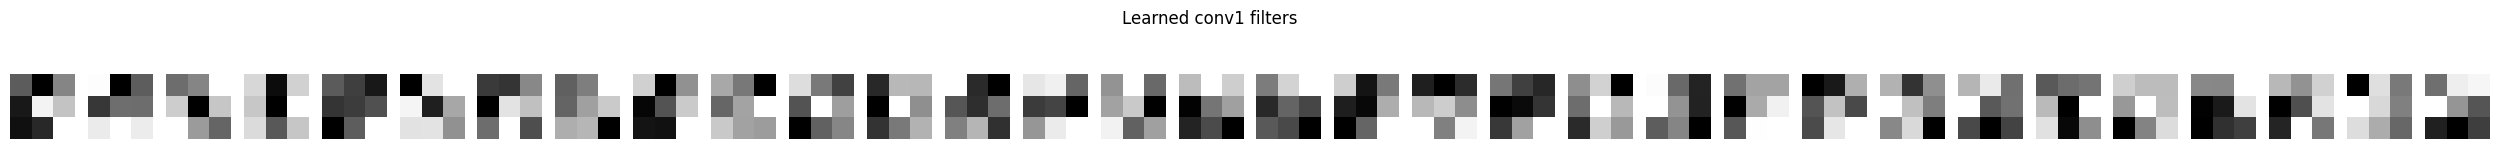

In [21]:
# Visualize learned conv1 filters
# (Adapt from Part 1 of the visualization tutorial)

# Visualize learned conv1 filters
# (Adapt from Part 1 of the visualization tutorial)

import matplotlib.pyplot as plt

# get conv1 weights
weights = model.conv1.weight.data.cpu()

# normalize weights to 0–1
weights = (weights - weights.min()) / (weights.max() - weights.min())

num_filters = weights.shape[0]

fig, axes = plt.subplots(1, num_filters, figsize=(num_filters, 2))

for i in range(num_filters):
    axes[i].imshow(weights[i, 0], cmap='gray')
    axes[i].axis('off')

plt.suptitle("Learned conv1 filters")
plt.show()


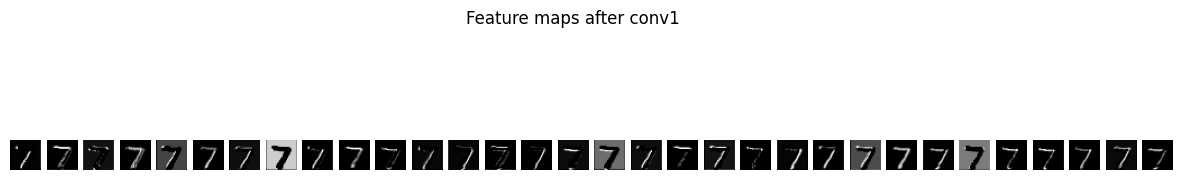

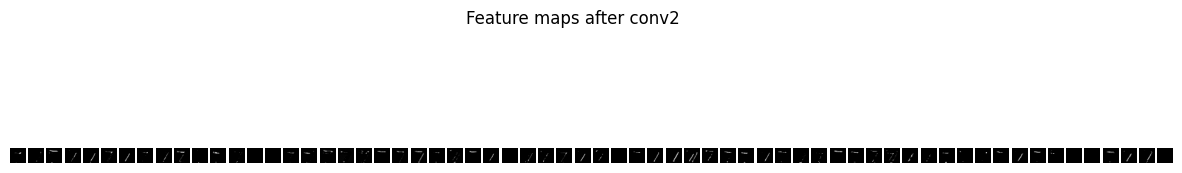

In [23]:
# Visualize intermediate feature maps on a sample MNIST digit
# (Adapt from Part 2 of the visualization tutorial)

# Visualize intermediate feature maps on a sample MNIST digit
# (Adapt from Part 2 of the visualization tutorial)

import torch
import matplotlib.pyplot as plt

# get one image from test set
data_iter = iter(test_loader)
images, labels = next(data_iter)

device = next(model.parameters()).device  # gets model device
image = images[0].unsqueeze(0).to(device)

# pass through conv1
x = model.conv1(image)
x = torch.relu(x)

# plot feature maps after conv1
fig, axes = plt.subplots(1, x.shape[1], figsize=(15, 3))

for i in range(x.shape[1]):
    axes[i].imshow(x[0, i].detach().cpu(), cmap='gray')
    axes[i].axis('off')

plt.suptitle("Feature maps after conv1")
plt.show()


# OPTIONAL: if you have conv2
if hasattr(model, 'conv2'):
    x = model.conv2(x)
    x = torch.relu(x)

    fig, axes = plt.subplots(1, x.shape[1], figsize=(15, 3))

    for i in range(x.shape[1]):
        axes[i].imshow(x[0, i].detach().cpu(), cmap='gray')
        axes[i].axis('off')

    plt.suptitle("Feature maps after conv2")
    plt.show()


---

## Deliverables

Submit two files:

### 1. This notebook (`.ipynb`)

Your complete, executed notebook containing all code, outputs, and results for Parts 1–7. The notebook should run top to bottom without errors.

### 2. Writeup (`.md` or `.pdf`)

A short report (1–2 pages) covering:

- **Baseline comparison:** MLP vs. base CNN — what was the accuracy difference? Why does the CNN do better (or not)?
- **Experiment summary:** A table of all your MLflow runs showing architecture, key hyperparameters, and test accuracy.
- **Analysis of experiments:** For each experiment in Parts 4 and 5, what did you change, what did you expect, and what happened? Reference your MLflow metrics.
- **Visualization discussion:** What do the learned filters look like? How do the feature maps relate to the input?
- **Reflection:** What surprised you? If you had another week, what would you try next?

---

## Grading Rubric

| Component | Points |
|-----------|--------|
| CNN classifier (working, logged) | 20 |
| Kernel size / filter count experiments (at least two, logged) | 20 |
| Open exploration (at least one, logged) | 20 |
| MLflow logging (all runs, parameters, tags, confusion matrices) | 20 |
| Visualization (learned filters + intermediate feature maps) | 20 |
| Writeup (comparison, analysis, reflection) | 50 |
| **Total** | **150** |

---

## Tips

- **Start with Part 2.** If your MLP training loop works, everything else is a model swap.
- **Reuse code.** Write a `train_and_evaluate` function that takes a model, trains it, evaluates it, and logs everything to MLflow. Then call it for each experiment. You'll thank yourself.
- **Track your shapes.** Most CNN bugs are shape mismatches. Print `x.shape` after each layer, or use the shape-tracing technique from Day 2.
- **Don't overtrain.** MNIST is a small dataset. If your model isn't converging in 5–10 epochs, something is wrong with the setup, not the number of epochs.
- **Name your MLflow runs.** Future-you will thank present-you when comparing 8 runs in the MLflow UI.